In [57]:
import os
import torch
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load prediction results
video_root = r"D:\jzhao\DeepVOG-project\3DeepVOG\sample_video\patient_sample"
ellipse_path = os.path.join(video_root, "log", "predict", "ellipses.pkl")
gaze_path = os.path.join(video_root, "log", "predict", "gaze.pkl")
torsion_path = os.path.join(video_root, "log", "predict", "torsion.pkl")

ellipse_out = pd.read_pickle(ellipse_path)
gaze_out = pd.read_pickle(gaze_path)
torsion_out = pd.read_pickle(torsion_path)

video_path = os.path.join(video_root, "trial.mp4")
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f"FPS: {fps}")
print(f"Total frames: {frame_count}")
print(f"Duration (sec): {frame_count / fps if fps > 0 else 'unknown'}")

FPS: 220.717
Total frames: 11054
Duration (sec): 50.08223199844144


In [58]:
len(ellipse_out), len(gaze_out), len(torsion_out)

(11054, 11054, 11054)

### ellipse_out contains:
- fitted pupil & iris ellipse parameters (cx, cy, a, b, radian)
- confidence: higher -> fitted well
- blink (binary: open=0, blink=1)

In [59]:
ellipse_out

,pupil_center_x,pupil_center_y,pupil_w,pupil_h,pupil_radius,pupil_radian,pupil_confidence,iris_center_x,iris_center_y,iris_w,iris_h,iris_radius,iris_radian,iris_confidence,blink,is_valid
0,94.370445,80.515289,22.660162,23.858297,23.259230,1.126182,0.989776,96.417557,84.583672,50.275639,64.697807,57.486725,1.517949,0.986840,0.0,1.0
1,94.410973,80.546455,22.581312,23.851191,23.216251,1.102270,0.990038,96.225853,84.513802,50.181793,64.795021,57.488407,1.518343,0.986851,0.0,1.0
2,94.537544,80.584473,22.575508,23.883945,23.229727,1.131059,0.991412,96.180367,84.431831,49.994946,64.898262,57.446602,1.515364,0.987334,0.0,1.0
3,94.656395,80.617638,22.604603,23.852451,23.228527,1.101985,0.990537,96.327469,84.478378,50.678036,64.895424,57.786728,1.515213,0.986600,0.0,1.0
4,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,102.418991,105.521385,15.070781,18.200846,16.635813,1.098153,0.001382,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11049,79.452454,84.162773,18.741674,19.795341,19.268509,0.568808,0.994789,82.341621,85.212936,50.258163,62.279980,56.269073,1.502597,0.978006,0.0,1.0
11050,79.534386,84.187172,18.847389,19.764765,19.306076,0.507689,0.993410,82.465126,85.192657,50.498394,62.301083,56.399738,1.500061,0.976397,0.0,1.0
11051,79.561707,84.202156,18.860878,19.748686,19.304783,0.518906,0.995086,82.524910,84.984924,49.333324,62.688660,56.010994,1.506395,0.978400,0.0,1.0
11052,79.651665,84.192551,18.841858,19.760786,19.301323,0.440985,0.994465,82.630730,85.226791,49.803925,62.462807,56.133366,1.490226,0.979936,0.0,1.0


In [60]:
gaze_out

,timestamp,c_eye_x,c_eye_y,c_eye_z,r_eye,c_eye2d_x,c_eye2d_y,r_eye2d,c_pupil_x,c_pupil_y,...,location_x,location_y,diameter,confidence,model_confidence,norm_pos_x,norm_pos_y,norm_pos_2,hor,ver
0,0.000000,-1.738721,-3.702439,3.184998,10.392304,-7856.431152,-16804.527344,59356.691406,-0.018668,-0.531158,...,94.370445,80.515289,47.716595,0.989776,0.1,0.501970,0.329039,0.670961,10.008965,-17.767590
1,0.004531,2.405099,4.897814,65.143448,10.392304,115.466904,104.314949,111.751099,0.175923,2.068022,...,94.453667,80.483253,47.707882,0.990038,1.0,0.502413,0.329306,0.670694,-12.880958,15.800986
2,0.009061,2.405099,4.897814,65.143448,10.392304,115.466904,104.314949,111.751099,0.187690,2.070619,...,94.585274,80.514122,47.773762,0.991412,1.0,0.503113,0.329049,0.670951,-12.810845,15.786103
3,0.013592,2.405099,4.897814,65.143448,10.392304,115.466904,104.314949,111.751099,0.197810,2.074264,...,94.698067,80.555870,47.710289,0.990537,1.0,0.503713,0.328701,0.671299,-12.750057,15.765224
4,0.018123,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,90.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11049,50.059578,2.405099,4.897814,65.143448,10.392304,115.466904,104.314949,111.751099,-1.163253,2.418124,...,79.482819,84.166573,39.591385,0.994789,1.0,0.422781,0.298612,0.701388,-20.706284,13.804413
11050,50.064110,2.405099,4.897814,65.143448,10.392304,115.466904,104.314949,111.751099,-1.155558,2.421589,...,79.568024,84.207001,39.530590,0.993410,1.0,0.423234,0.298275,0.701725,-20.657770,13.784741
11051,50.068642,2.405099,4.897814,65.143448,10.392304,115.466904,104.314949,111.751099,-1.152797,2.422824,...,79.598549,84.221359,39.498447,0.995086,1.0,0.423397,0.298155,0.701845,-20.640373,13.777727
11052,50.073170,2.405099,4.897814,65.143448,10.392304,115.466904,104.314949,111.751099,-1.145612,2.422859,...,79.678619,84.223465,39.523064,0.994465,1.0,0.423822,0.298138,0.701862,-20.596775,13.777529


Since the torsion component is susceptible to off-axis viewing directions (affine transformations), we filter out drift signals from the torsion channel. Future work will address this issue by modeling the actual 3D geometry of the eyeball (Comming soon!)

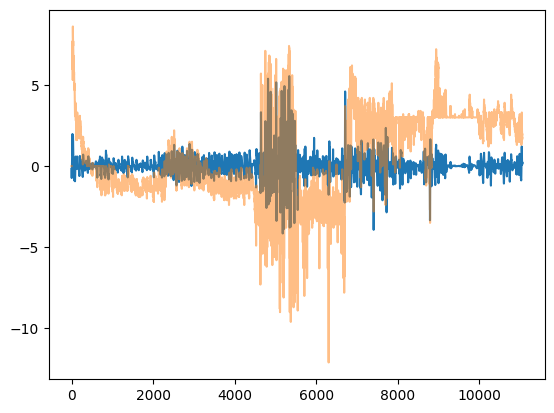

In [ ]:
from threedeepvog.utils.torsion_process import clean_signal
torsion_comp = clean_signal(torsion_out, fps= fps, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4)
plt.plot(torsion_comp, label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)

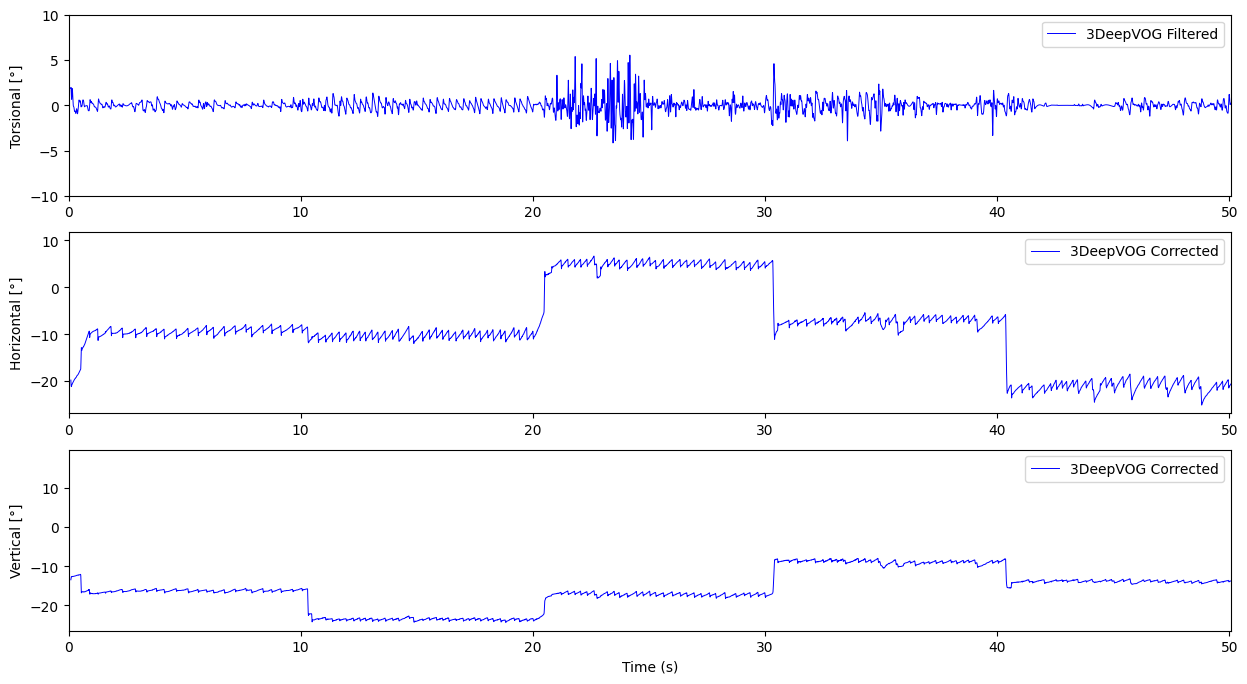

In [ ]:
blink_ix = np.array(gaze_out['confidence'])<0.975
frame_time = np.arange(len(torsion_out)) / fps
hor_comp, ver_comp = gaze_out['hor'], gaze_out['ver']
hor_comp[blink_ix]  = np.nan
ver_comp[blink_ix]  = np.nan
torsion_comp[blink_ix] = np.nan

plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)

# plt.plot(frame_time, torsion_out[:len(frame_time)], label='3DeepVOG Raw', alpha=0.5, linewidth=0.7)
plt.plot(frame_time, torsion_comp[:len(frame_time)], label='3DeepVOG Filtered', linewidth=0.7, color='blue')
# plt.xlabel('Time (s)')
plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.ylabel('Torsional [°]')
plt.legend()

plt.subplot(3, 1, 2)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# ax_hor.axvspan(start_f, end_f, color='gray', alpha=0.3)
# plt.plot(frame_time, gaze_x[:len(frame_time)], label='Predicted')
# plt.plot(frame_time, GT_x[:len(frame_time)], label='EyeSeeCam', linewidth=0.7, color='red')
plt.plot(frame_time, hor_comp[:len(frame_time)], label='3DeepVOG Corrected', linewidth=0.7, color='blue')
# plt.xlabel('Time (s)')
plt.ylabel('Horizontal [°]')
# plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.legend()

plt.subplot(3, 1, 3)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# plt.plot(frame_time, gaze_y[:len(frame_time)], label='Predicted')
# plt.plot(frame_time, -GT_y[:len(frame_time)], label='EyeSeeCam', linewidth=0.7, color='red')
plt.plot(frame_time, -ver_comp[:len(frame_time)], label='3DeepVOG Corrected', linewidth=0.7, color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Vertical [°]')
# plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.legend()

plt.savefig(r"C:\Users\jzhao\Downloads\patient_ex.pdf", format='pdf')

If you have a ground-truth (GT) signal, you can use it to generate a calibration matrix that converts horizontal and vertical gaze components from camera coordinates to world coordinates.

In [ ]:
from scipy.optimize import minimize
from threedeepvog.utils.cart2sph import cart2sph_batch_PL

def gen_calib_matrix(df_GT, normals, conf, thr_confidence=0.96, default_M = np.eye(3), opt_flag = True):
    GT_x, GT_y = np.rad2deg(df_GT.hor), -np.rad2deg(df_GT.ver)
    GT_x = GT_x - np.nanmean(GT_x)
    GT_y = GT_y - np.nanmean(GT_y)
    pred_full = np.full_like(GT_x, np.nan)
    pred_y_full = np.full_like(GT_y, np.nan)

    valid = ~np.isnan(GT_x) & ~np.isnan(GT_y) & ~np.isnan(normals).any(0)
    GT_x, GT_y, normals, conf = GT_x[valid], GT_y[valid], normals[:, valid], conf[valid]

    def loss(params):
        M = params.reshape(3, 3)
        pred_x, pred_y = cart2sph_batch_PL(M @ normals)
        pred_x[conf < thr_confidence] = np.nan
        pred_y[conf < thr_confidence] = np.nan
        pred_x -= np.nanmean(pred_x)
        pred_y -= np.nanmean(pred_y)
        err_x = np.abs(pred_x - GT_x)
        err_y = np.abs(pred_y - GT_y)
        # err_x, err_y = extract_range(np.abs(pred_x - GT_x), np.abs(pred_y - GT_y), mov_ranges)
        return np.nanmedian(err_x) + np.nanmedian(err_y)
    
    if opt_flag:
        res = minimize(loss, default_M.flatten(), method='L-BFGS-B')
        M_opt = res.x.reshape(3, 3)
    else:
        M_opt = default_M

    pred = M_opt @ normals
    fx, fy = np.zeros_like(GT_x), np.zeros_like(GT_y)
    fx[:], fy[:] = cart2sph_batch_PL(pred)
    fx[conf < thr_confidence] = np.nan
    fy[conf < thr_confidence] = np.nan
    fx -= np.nanmean(fx)
    fy -= np.nanmean(fy)
    # Insert predictions into full-length arrays
    pred_full[valid] = fx
    pred_y_full[valid] = fy
    return pred_full, pred_y_full, M_opt

# df_gaze_GT = pd.read_csv(r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub3\trial.csv")
# GT_x, GT_y = np.rad2deg(df_gaze_GT.hor), -np.rad2deg(df_gaze_GT.ver)
# GT_x = GT_x - np.nanmean(GT_x)
# GT_y = GT_y - np.nanmean(GT_y)
# frame_time = np.arange(len(GT_x)) / fps
# gaze_x, gaze_y = gaze_extract_LG(df_gaze_out)
# normals = df_gaze_out.loc[:, ['pupil_3D_norm_x', 'pupil_3D_norm_y', 'pupil_3D_norm_z']].values.T
# conf = df_gaze_out.loc[:, 'confidence'].values
# final_x, final_y, opt_M = opt_transform_v2(df_gaze_GT, normals, conf, thr_confidence=0.96, default_M=np.eye(3), opt_flag=True)
